In [11]:

inp = "/media/data/datasets/mri_database/IXI/subjects/IXI115/IXI115-Guys-0738-T1.nii.gz"
out = "/home/lemuel/Documents/temp/pet.nii.gz"

! mri2pet --i {inp} --o {out} --m 4 --preprocess --preprocess_out /home/lemuel/Documents/temp/prepro

╭────────────────────────────────── CoCoLIT ───────────────────────────────────╮
│                                                                              │
│                                                                              │
│       If you use this work for your research, please cite:                   │
│                                                                              │
│       "CoCoLIT: ControlNet-Conditioned Latent Image Translation for MRI to   │
│   Amyloid PET Synthesis."                                                    │
│       Alec Sargood*, Lemuel Puglisi*, James Cole, Neil Oxtoby, Daniele       │
│   Ravì, Daniel C. Alexander                                                  │
│       *Joint first authors.                                                  │
│                                                                              │
│                                                                              │
╰───────────────────────────

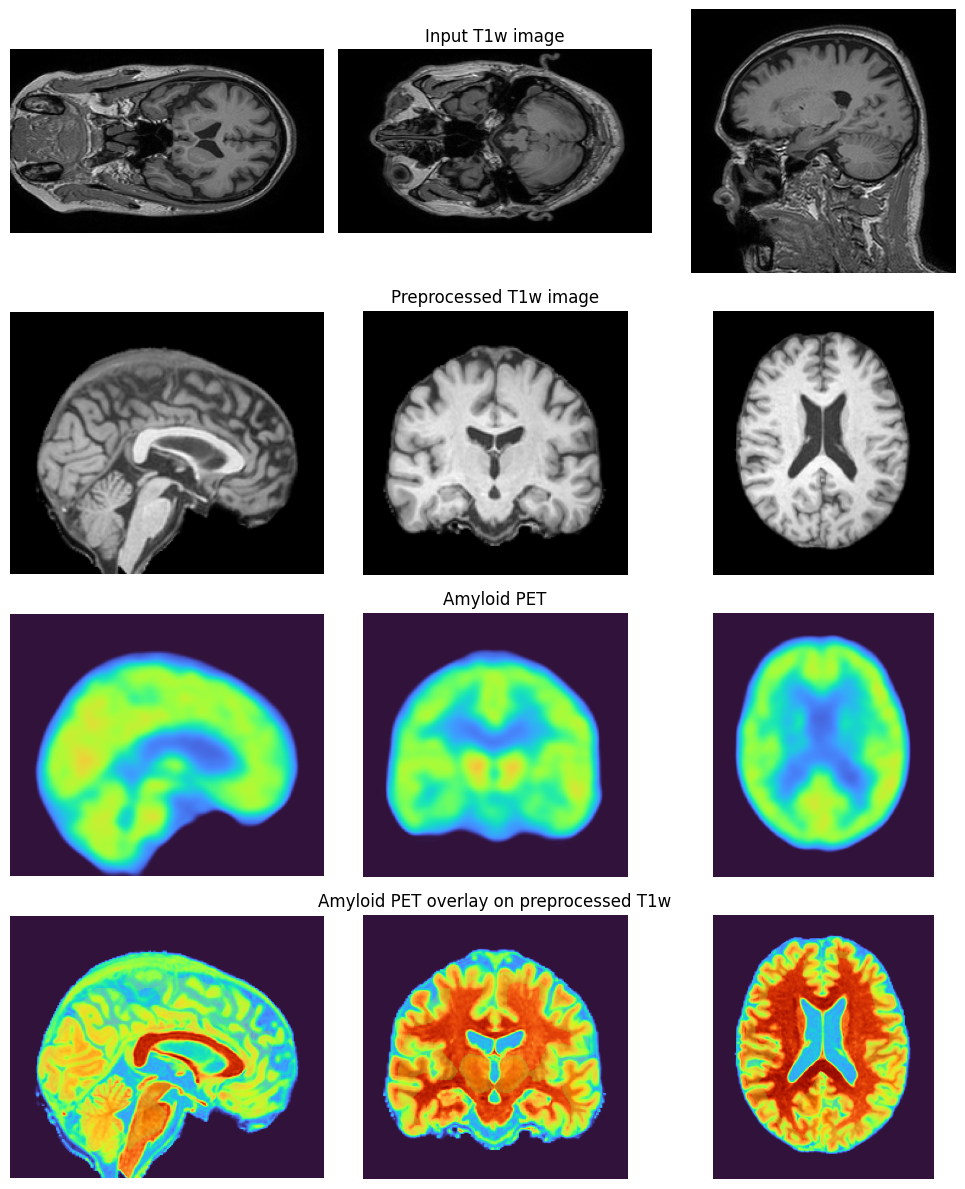

In [20]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

overlay_alpha = 0.3
suvr_threshold = 1.326
pet_vmin, pet_vmax = 0, 3.0

# Load volumes
scan = nib.load(inp).get_fdata()
prep = nib.load("/home/lemuel/Documents/temp/prepro/norm_mni_space.nii.gz").get_fdata()
pet  = nib.load(out).get_fdata()

# Middle slices from reference space
x, y, z = np.array(prep.shape) // 2

def slices(vol):
    return [
        vol[x, :, :].T,   # sagittal
        vol[:, y, :].T,   # coronal
        vol[:, :, z].T    # axial
    ]

scan_sl = slices(scan)
prep_sl = slices(prep)
pet_sl  = slices(pet)

fig, ax = plt.subplots(4, 3, figsize=(10, 12))
for a in ax.ravel():
    a.set_axis_off()

# Row 1: input MRI
for i, s in enumerate(scan_sl):
    ax[0, i].imshow(s, cmap="gray", origin="lower")

# Row 2: preprocessed MRI
for i, s in enumerate(prep_sl):
    ax[1, i].imshow(s, cmap="gray", origin="lower")

# Row 3: amyloid PET alone
for i, s in enumerate(pet_sl):
    ax[2, i].imshow(s, cmap="turbo", origin="lower", vmin=0, vmax=pet_vmax)

# Row 4: PET overlay on preprocessed MRI
for i, (mri, p) in enumerate(zip(prep_sl, pet_sl)):
    alpha = np.where(p >= suvr_threshold, overlay_alpha, 0.0)
    ax[3, i].imshow(mri, cmap="gray", origin="lower")
    ax[3, i].imshow(p, cmap="turbo", origin="lower",
                    vmin=pet_vmin, vmax=pet_vmax, alpha=alpha)

ax[0, 1].set_title("Input T1w image")
ax[1, 1].set_title("Preprocessed T1w image")
ax[2, 1].set_title("Amyloid PET")
ax[3, 1].set_title("Amyloid PET overlay on preprocessed T1w")

fig.tight_layout()
plt.show()